In [3]:
from pathlib import Path

base_dir = Path.cwd()
folders = {
    "Antarctic": base_dir / "Antarctic",
    "Bipolar": base_dir / "Bipolar",
    "Greenland": base_dir / "Greenland",
    "all_tiepoints": base_dir / "all_tiepoints",
}


def count_tiepoints(txt_path: Path) -> int:
    with txt_path.open(encoding="utf-8") as handle:
        data_lines = [line for line in handle if line.strip() and not line.lstrip().startswith("#")]
    return max(len(data_lines) - 1, 0)


summary_rows = []
for folder_name, folder_path in folders.items():
    folder_total = 0
    print(folder_name)
    print("-" * len(folder_name))

    linkage_dirs = sorted(
        entry for entry in folder_path.iterdir()
        if entry.is_dir() and entry.name != "Chronologies"
    )

    for linkage_dir in linkage_dirs:
        txt_files = sorted(linkage_dir.glob("*.txt"))
        linkage_total = sum(count_tiepoints(txt_file) for txt_file in txt_files)
        folder_total += linkage_total
        summary_rows.append(
            {
                "folder": folder_name,
                "linkage": linkage_dir.name,
                "txt_files": len(txt_files),
                "tiepoints": linkage_total,
            }
        )
        print(f"{linkage_dir.name}: {linkage_total}")

    print(f"Total: {folder_total}\n")

summary_rows

Antarctic
---------
DF-TALDICE: 111
EDC-DF: 1605
EDC-EDML: 828
EDC-TALDICE: 246
EDC-WDC: 897
EDML-DF: 215
EDML-TALDICE: 128
WDC-DF: 1078
WDC-EDML: 1315
WDC-TALDICE: 1219
Total: 7642

Bipolar
-------
GISP2-DF: 118
GISP2-EDC: 138
GISP2-EDML: 155
GISP2-TALDICE: 89
GISP2-WDC: 299
GRIP-DF: 107
GRIP-EDC: 119
GRIP-EDML: 127
GRIP-TALDICE: 74
GRIP-WDC: 296
NEEM-DF: 132
NEEM-EDC: 155
NEEM-EDML: 168
NEEM-TALDICE: 86
NEEM-WDC: 112
NG1-EDML: 112
NG2-DF: 215
NG2-EDC: 269
NG2-EDML: 353
NG2-TALDICE: 128
NG2-WDC: 192
Total: 3444

Greenland
---------
GISP2-GRIP: 918
GISP2-NEEM: 194
GISP2-NG1: 290
GISP2-NG2: 725
NEEM-GRIP: 396
NG1-GRIP: 587
NG1-NEEM: 673
NG1-NG2: 311
NG2-GRIP: 1003
NG2-NEEM: 886
Total: 5983

all_tiepoints
-------------
DF-EDC: 1605
DF-EDML: 215
DF-TALDICE: 111
DF-WDC: 1078
EDC-EDML: 828
EDC-WDC: 897
EDML-WDC: 1315
GISP2-DF: 118
GISP2-EDC: 138
GISP2-EDML: 155
GISP2-GRIP: 918
GISP2-NEEM: 194
GISP2-NG1: 290
GISP2-NG2: 725
GISP2-TALDICE: 89
GISP2-WDC: 299
GRIP-DF: 107
GRIP-EDC: 119
GRIP-EDML

[{'folder': 'Antarctic',
  'linkage': 'DF-TALDICE',
  'txt_files': 1,
  'tiepoints': 111},
 {'folder': 'Antarctic',
  'linkage': 'EDC-DF',
  'txt_files': 2,
  'tiepoints': 1605},
 {'folder': 'Antarctic',
  'linkage': 'EDC-EDML',
  'txt_files': 3,
  'tiepoints': 828},
 {'folder': 'Antarctic',
  'linkage': 'EDC-TALDICE',
  'txt_files': 2,
  'tiepoints': 246},
 {'folder': 'Antarctic',
  'linkage': 'EDC-WDC',
  'txt_files': 3,
  'tiepoints': 897},
 {'folder': 'Antarctic',
  'linkage': 'EDML-DF',
  'txt_files': 1,
  'tiepoints': 215},
 {'folder': 'Antarctic',
  'linkage': 'EDML-TALDICE',
  'txt_files': 1,
  'tiepoints': 128},
 {'folder': 'Antarctic',
  'linkage': 'WDC-DF',
  'txt_files': 4,
  'tiepoints': 1078},
 {'folder': 'Antarctic',
  'linkage': 'WDC-EDML',
  'txt_files': 3,
  'tiepoints': 1315},
 {'folder': 'Antarctic',
  'linkage': 'WDC-TALDICE',
  'txt_files': 3,
  'tiepoints': 1219},
 {'folder': 'Bipolar',
  'linkage': 'GISP2-DF',
  'txt_files': 1,
  'tiepoints': 118},
 {'folder': '

In [10]:
import pandas as pd

# Point this to Antarctic, Bipolar, Greenland, or all_tiepoints.
tiepoint_root = base_dir / "all_tiepoints"

records = []
for linkage_dir in sorted(p for p in tiepoint_root.iterdir() if p.is_dir() and p.name != "Chronologies"):
    if "-" not in linkage_dir.name:
        continue

    core_a, core_b = linkage_dir.name.split("-", 1)
    for txt_file in sorted(linkage_dir.glob("*.txt")):
        df = pd.read_csv(
            txt_file,
            comment="#",
            sep=r"\s+|\t+|,",
            engine="python",
        )

        norm_cols = {c.lower().strip(): c for c in df.columns}
        if "depth1" not in norm_cols or "depth2" not in norm_cols:
            continue

        depth1_col = norm_cols["depth1"]
        depth2_col = norm_cols["depth2"]
        reference_col = norm_cols.get("reference")

        for _, row in df.iterrows():
            records.append(
                {
                    "core1": core_a,
                    "core2": core_b,
                    "core1_depth": float(row[depth1_col]),
                    "core2_depth": float(row[depth2_col]),
                    "reference": None if reference_col is None else row[reference_col],
                }
            )

tiepoint_df = pd.DataFrame(
    records,
    columns=["core1", "core2", "core1_depth", "core2_depth", "reference"],
)


def get_pair_tiepoints(core1: str, core2: str, df: pd.DataFrame = tiepoint_df) -> pd.DataFrame:
    direct = df[(df["core1"] == core1) & (df["core2"] == core2)].copy()

    flipped = df[(df["core1"] == core2) & (df["core2"] == core1)].copy()
    if not flipped.empty:
        flipped = flipped.rename(
            columns={
                "core1": "core2",
                "core2": "core1",
                "core1_depth": "core2_depth",
                "core2_depth": "core1_depth",
            }
        )
        flipped = flipped[["core1", "core2", "core1_depth", "core2_depth", "reference"]]

    out = pd.concat([direct, flipped], ignore_index=True)
    return out.sort_values("core1_depth").reset_index(drop=True)


# Example: get EDC (x) vs WDC (y) tiepoints
pair = get_pair_tiepoints("WDC", "TALDICE")

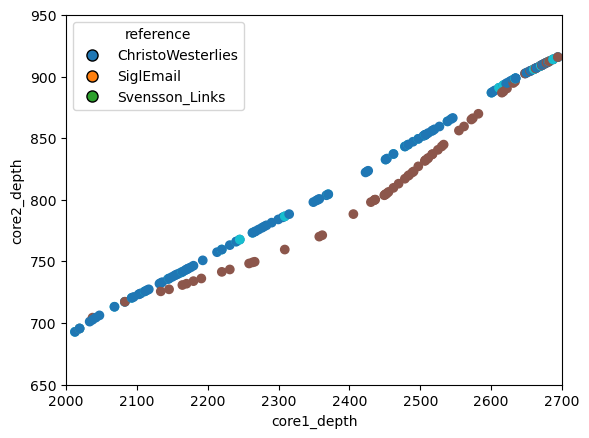

In [34]:
import matplotlib.pyplot as plt

# Convert reference to categorical codes for coloring
categories = pair["reference"].astype("category")
colors = categories.cat.codes

scatter = plt.scatter(pair["core1_depth"], pair["core2_depth"], c=colors, cmap="tab10")
plt.xlabel("core1_depth")
plt.ylabel("core2_depth")
plt.xlim(2000,2700)
plt.ylim(650,950)

# Create a legend with category labels
handles = []
labels = categories.cat.categories
for i, label in enumerate(labels):
    handles.append(plt.Line2D([], [], marker="o", color="w", markerfacecolor=plt.cm.tab10(i), label=label, markersize=8, markeredgecolor='k'))
plt.legend(handles=handles, title="reference")
plt.show()